<a href="https://colab.research.google.com/github/did35/TemperatureDataset/blob/main/TemperatureAnomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTE TO FUTURE ME
#
# Before plotting anything:
#
# 1. Understand the dataset.
# 2. Check column meanings.
# 3. Check missing values.
# 4. Rename columns.
# 5. Only then start analysis.
#
# "Never trust a dataset you haven't explored."

In [20]:
# ==========================================================
# Berkeley Earth - Global Land Temperature Dataset
#
# Goal:
# Download and load the Berkeley Earth monthly temperature
# anomaly dataset into a Pandas DataFrame for analysis.
#
# Dataset:
# https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Regional/TAVG/global-land-TAVG-Trend.txt
#
# Columns (simplified):
# 0 = Year
# 1 = Month
# 2 = Monthly temperature anomaly (°C)
# 3 = Estimated uncertainty
# Additional columns contain confidence intervals and
# statistical bounds.
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Berkeley Earth dataset URL
url = (
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/"
    "Regional/TAVG/global-land-TAVG-Trend.txt"
)

# Read the file:
# - Ignore comment lines beginning with %
# - Columns separated by variable whitespace
# - No header row provided in source file
df = pd.read_csv(
    url,
    comment="%",
    sep=r"\s+",
    header=None
)

# Quick inspection
df.head()

# Structure and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3252 entries, 0 to 3251
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       3252 non-null   int64  
 1   1       3252 non-null   int64  
 2   2       3251 non-null   float64
 3   3       3251 non-null   float64
 4   4       3233 non-null   float64
 5   5       3233 non-null   float64
 6   6       3160 non-null   float64
 7   7       3160 non-null   float64
 8   8       3100 non-null   float64
 9   9       3100 non-null   float64
 10  10      2980 non-null   float64
 11  11      2980 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 305.0 KB


## Why comment="%" ?

The Berkeley Earth file starts with metadata lines such as:

% Monthly Land Temperature


% Berkeley Earth

% ...

Without comment="%", Pandas would try to read those lines as data.


## Why sep=r"\s+" ?

The file is not comma-separated.

Instead it looks like:

1750 1 -0.466 2.805

1750 2 -0.836 3.025

## \s+ means:

One or more whitespace characters.

This handles any number of spaces or tabs.

## Why header=None ?

The dataset has no column names.

Pandas therefore creates numeric column labels:

0, 1, 2, 3, ...

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3252 entries, 0 to 3251
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       3252 non-null   int64  
 1   1       3252 non-null   int64  
 2   2       3251 non-null   float64
 3   3       3251 non-null   float64
 4   4       3233 non-null   float64
 5   5       3233 non-null   float64
 6   6       3160 non-null   float64
 7   7       3160 non-null   float64
 8   8       3100 non-null   float64
 9   9       3100 non-null   float64
 10  10      2980 non-null   float64
 11  11      2980 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 305.0 KB


In [21]:
# ==========================================================
# Assign meaningful column names
#
# Berkeley Earth provides:
#
# Monthly values
# Annual values
# 5-year smoothed values
# 10-year smoothed values
# 20-year smoothed values
#
# Each anomaly has an associated uncertainty estimate.
# ==========================================================

df.columns = [
    "Year",
    "Month",

    # Monthly temperature anomaly
    "MonthlyAnomaly",
    "MonthlyUncertainty",

    # Annual anomaly
    "AnnualAnomaly",
    "AnnualUncertainty",

    # 5-year running average
    "FiveYearAnomaly",
    "FiveYearUncertainty",

    # 10-year running average
    "TenYearAnomaly",
    "TenYearUncertainty",

    # 20-year running average
    "TwentyYearAnomaly",
    "TwentyYearUncertainty"
]

# Verify column assignment
df.head()

,Year,Month,MonthlyAnomaly,MonthlyUncertainty,AnnualAnomaly,AnnualUncertainty,FiveYearAnomaly,FiveYearUncertainty,TenYearAnomaly,TenYearUncertainty,TwentyYearAnomaly,TwentyYearUncertainty
0,1750,1,-0.466,2.805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1750,2,-0.836,3.025,-0.606,0.805,NaN,NaN,NaN,NaN,NaN,NaN
2,1750,3,0.678,2.494,-0.626,0.818,NaN,NaN,NaN,NaN,NaN,NaN
3,1750,4,0.095,1.240,-0.658,0.820,NaN,NaN,NaN,NaN,NaN,NaN
4,1750,5,-1.205,1.153,-0.971,0.823,NaN,NaN,NaN,NaN,NaN,NaN


What is an anomaly?

Temperature anomaly means:

Observed temperature
minus
Reference temperature

Example:

Reference = 14.0°C
Observed = 14.8°C

Anomaly = +0.8°C

Climate datasets usually analyze anomalies rather than absolute temperatures.

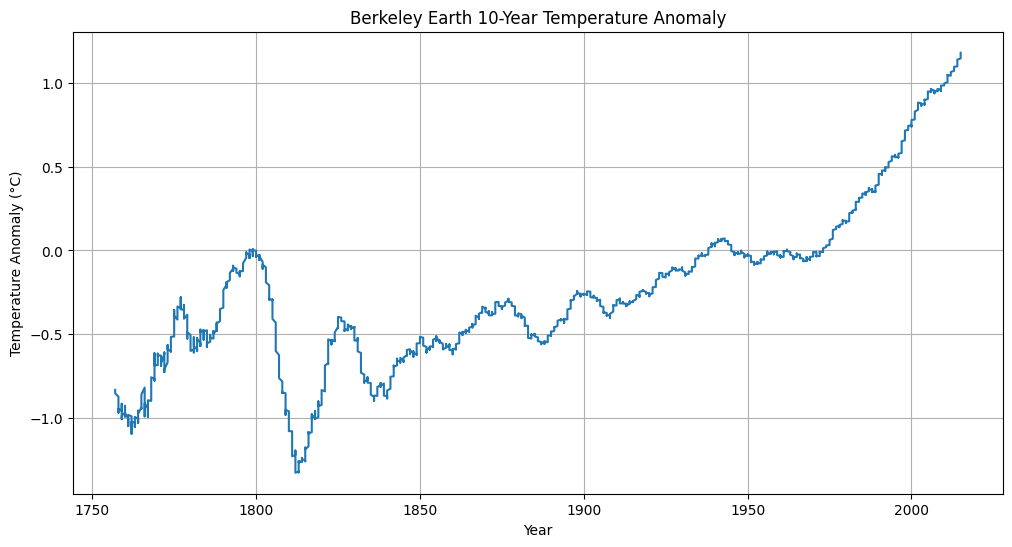

In [22]:
# ==========================================================
# Plot the Berkeley Earth 10-Year Temperature Anomaly
#
# Why use the 10-year anomaly?
#
# - Removes most monthly variability
# - Reduces year-to-year noise
# - Makes long-term trends easier to see
# - Good compromise between detail and smoothing
# ==========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["Year"],
    df["TenYearAnomaly"]
)

plt.title("Berkeley Earth 10-Year Temperature Anomaly")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)

plt.show()

## First Observations

The temperature anomaly does not increase smoothly.

Several periods of warming and cooling can be observed:

- Late 1700s warming
- Early 1800s cooling (Dalton Minimum period)
- Recovery during the 19th century
- Relative stagnation around 1940–1975
- Rapid warming after ~1980

This graph alone does not explain why changes occurred.

It only describes what happened.

# First Derivative:

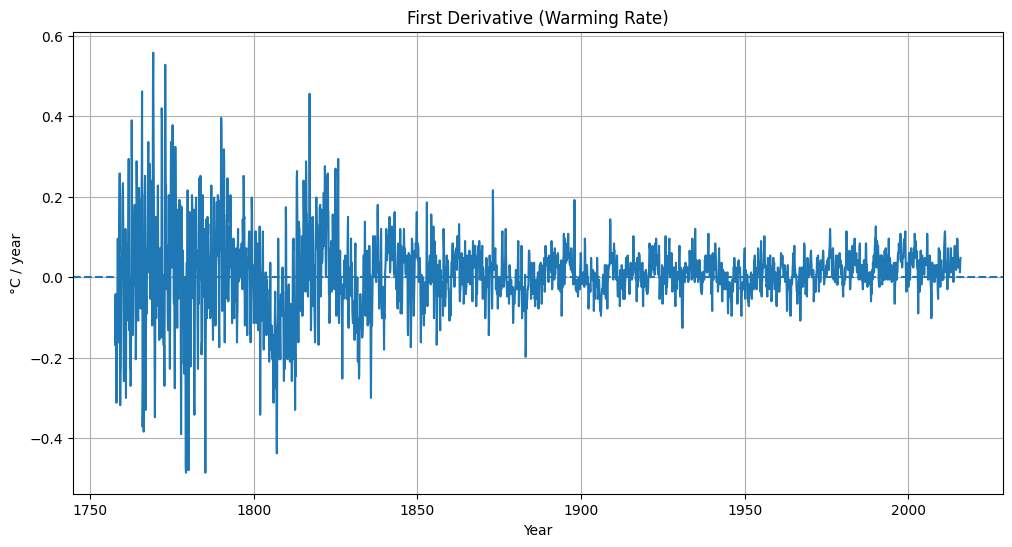

In [23]:
# ==========================================================
# FIRST DERIVATIVE
#
# Goal:
# Measure the warming/cooling rate.
#
# Interpretation:
#
# Positive slope  -> warming
# Negative slope  -> cooling
# Zero slope      -> stable temperature
#
# Units:
# °C per year
# ==========================================================

# Create a continuous time axis
# Example:
# Jan 2000 = 2000.00
# Jul 2000 = 2000.50
df["Time"] = df["Year"] + (df["Month"] - 1) / 12

# Remove rows where the 10-year anomaly is missing
ten_year = df.dropna(subset=["TenYearAnomaly"]).copy()

# Compute first derivative (slope)
ten_year["Slope"] = np.gradient(
    ten_year["TenYearAnomaly"],
    ten_year["Time"]
)

# Plot warming/cooling rate
plt.figure(figsize=(12, 6))

plt.plot(
    ten_year["Time"],
    ten_year["Slope"]
)

# Reference line:
# Above = warming
# Below = cooling
plt.axhline(
    0,
    linestyle="--"
)

plt.title("First Derivative (Warming Rate)")
plt.xlabel("Year")
plt.ylabel("°C / year")
plt.grid(True)

plt.show()

## How to read the first derivative

Temperature graph:
"How warm is it?"

First derivative:
"How fast is it warming or cooling?"

Examples:

Slope = +0.05 °C/year
→ warming by 0.05°C each year

Slope = 0
→ temperature stable

Slope = -0.05 °C/year
→ cooling by 0.05°C each year

# Second derivative:

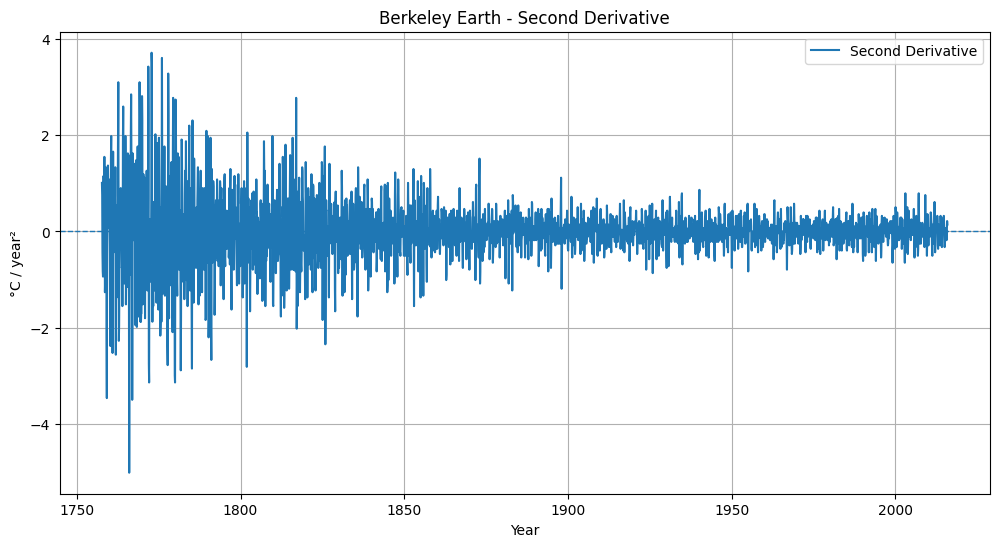

In [24]:
# ==========================================================
# SECOND DERIVATIVE
#
# Goal:
# Measure changes in the warming/cooling rate.
#
# Interpretation:
#
# Positive values:
#     Warming rate increasing
#     (positive acceleration)
#
# Negative values:
#     Warming rate decreasing
#     (negative acceleration)
#
# Units:
# °C / year²
#
# WARNING:
# Second derivatives amplify noise dramatically.
# ==========================================================

# Compute acceleration
ten_year["Acceleration"] = np.gradient(
    ten_year["Slope"],
    ten_year["Time"]
)

# Plot acceleration
plt.figure(figsize=(12, 6))

plt.plot(
    ten_year["Time"],
    ten_year["Acceleration"],
    label="Second Derivative"
)

# Reference line
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Berkeley Earth - Second Derivative")
plt.xlabel("Year")
plt.ylabel("°C / year²")

plt.grid(True)
plt.legend()

plt.show()

## How to read the second derivative

Temperature:
"How warm is it?"

First derivative:
"How fast is temperature changing?"

Second derivative:
"Is the warming/cooling rate itself increasing or decreasing?"

Examples:

Positive second derivative
→ warming speeding up

Negative second derivative
→ warming slowing down

Zero second derivative
→ warming rate unchanged

*Right now I've discovered something valuable: derivatives amplify noise. That's exactly why economists, climatologists, and engineers almost always smooth first and differentiate second. That's not a bug in my code; it's a property of the mathematics.*

# Smoothing first:

In [25]:
# ==========================================================
# SMOOTHING FIRST
#
# Goal:
# Convert monthly data into annual averages before
# computing derivatives.
#
# Why?
#
# Numerical differentiation amplifies noise.
# Averaging by year reduces short-term fluctuations
# and improves signal-to-noise ratio.
# ==========================================================

annual = (
    ten_year
    .groupby("Year")["TenYearAnomaly"]
    .mean()
    .reset_index()
)

# Verify result
annual.head()

,Year,TenYearAnomaly
0,1757,-0.843250
1,1758,-0.932833
2,1759,-0.974250
3,1760,-0.961417
4,1761,-1.021750


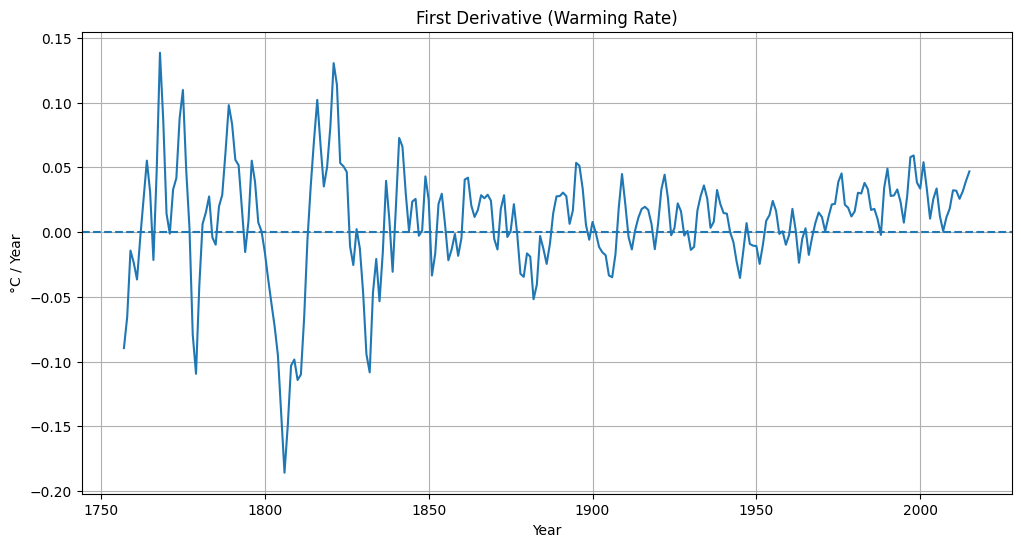

In [ ]:
# Remove rows where TenYearAnomaly is missing
ten_year = df.dropna(subset=["TenYearAnomaly"]).copy()

# Convert monthly data to yearly averages
annual = (
    ten_year
    .groupby("Year")["TenYearAnomaly"]
    .mean()
    .reset_index()
)

# First derivative (°C/year)
annual["Slope"] = np.gradient(
    annual["TenYearAnomaly"],
    annual["Year"]
)

# Plot first derivative
plt.figure(figsize=(12,6))

plt.plot(
    annual["Year"],
    annual["Slope"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("First Derivative (Warming Rate)")
plt.xlabel("Year")
plt.ylabel("°C / Year")

plt.grid(True)

plt.show()

## What does groupby() do?

In [ ]:
annual = (
    ten_year
    .groupby("Year")["TenYearAnomaly"]
    .mean()
)

Take all rows from 1757
→ compute average

Take all rows from 1758
→ compute average

Take all rows from 1759
→ compute average

...

## Signal vs Noise

Climate data contains:

Signal:
- long-term trends
- multi-decadal variability

Noise:
- seasonal variability
- measurement uncertainty
- short-term fluctuations

Before computing derivatives, reducing noise
often improves interpretation.

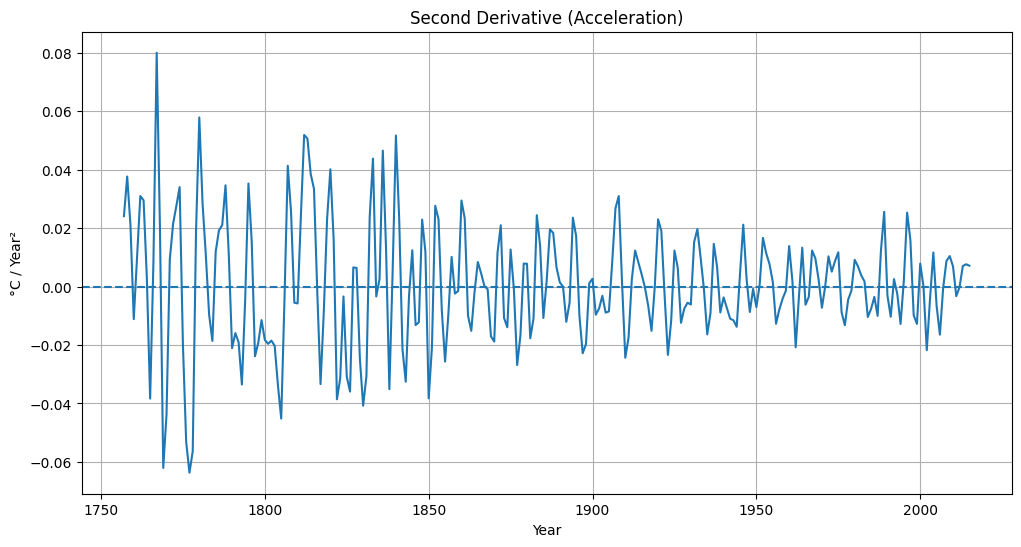

In [ ]:
# ==========================================================
# FIRST DERIVATIVE OF THE ANNUAL SERIES
#
# Goal:
# Estimate the warming/cooling rate after smoothing.
#
# Process:
#
# Monthly data
#      ↓
# 10-Year Anomaly
#      ↓
# Annual averages
#      ↓
# First derivative
#
# Result:
# A cleaner estimate of warming rate.
# ==========================================================

# Second derivative (°C/year²)
annual["Acceleration"] = np.gradient(
    annual["Slope"],
    annual["Year"]
)

# Plot second derivative
plt.figure(figsize=(12,6))

plt.plot(
    annual["Year"],
    annual["Acceleration"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Second Derivative (Acceleration)")
plt.xlabel("Year")
plt.ylabel("°C / Year²")

plt.grid(True)

plt.show()

## Interpretation

Positive values:
→ Temperature increasing

Negative values:
→ Temperature decreasing

Values near zero:
→ Little change in temperature

The graph represents the warming or cooling rate
of the 10-year anomaly.

In [ ]:
# ==========================================================
# Compare average warming rates for different periods.
#
# Questions:
#
# 1. Is the warming rate larger after 1975?
#
# 2. Has the warming rate itself increased since 2000?
#
# This is a simple exploratory comparison,
# not yet a formal statistical test.
# ==========================================================

print(
    annual.loc[annual["Year"] >= 1975, "Slope"].mean()
)

print(
    annual.loc[annual["Year"] < 1975, "Slope"].mean()
)

0.028119918699186994
0.0038216743119266054


In [ ]:
print(
    annual.loc[annual["Year"] >= 2000, "Slope"].mean()
)

print(
    annual.loc[
        (annual["Year"] >= 1975) &
        (annual["Year"] < 2000),
        "Slope"
    ].mean()
)

0.02758593750000001
0.02846166666666667


# pvalue

In [ ]:
from scipy.stats import linregress

recent = annual[annual["Year"] >= 1975]

result = linregress(
    recent["Year"],
    recent["Slope"]
)

print(result.slope)
print(result.pvalue)

9.672619047619125e-05
0.6202621990448385


# p-value

## Rule of Thumb

Small p-value (typically < 0.05)
→ the observed result would be unusual if the null hypothesis were true.

Large p-value
→ the observed result is reasonably compatible with the null hypothesis.

Important:

A p-value is not the probability that the null hypothesis is true.

A p-value measures how surprising the data would be if the null hypothesis were true.

## Important

Statistics does not prove a cause.

A statistically significant result only tells us:

"The observed difference is unlikely to be due to random variation alone."

Explaining *why* the difference exists is a separate scientific question.

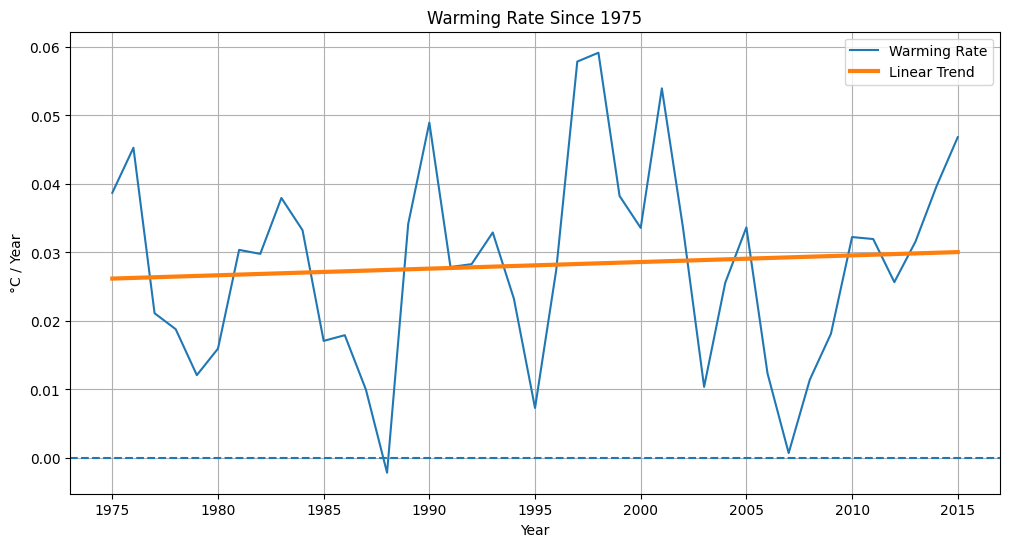

In [ ]:
# ==========================================================
# TREND IN THE WARMING RATE SINCE 1975
#
# Goal:
# Determine whether the warming rate itself
# shows a positive or negative trend.
#
# Method:
#
# 1. Compute annual warming rates
# 2. Select years >= 1975
# 3. Fit a linear regression
# 4. Examine slope and p-value
#
# Interpretation:
#
# Positive regression slope
#     -> warming rate increasing
#
# Negative regression slope
#     -> warming rate decreasing
#
# Near-zero regression slope
#     -> warming rate approximately stable
# ==========================================================

recent = annual[annual["Year"] >= 1975]

result = linregress(
    recent["Year"],
    recent["Slope"]
)

trend = (
    result.intercept
    + result.slope * recent["Year"]
)

plt.figure(figsize=(12,6))

plt.plot(
    recent["Year"],
    recent["Slope"],
    label="Warming Rate"
)

plt.plot(
    recent["Year"],
    trend,
    linewidth=3,
    label="Linear Trend"
)

plt.axhline(0, linestyle="--")

plt.title("Warming Rate Since 1975")
plt.xlabel("Year")
plt.ylabel("°C / Year")

plt.legend()
plt.grid(True)

plt.show()

## What linregress() does

In [ ]:
result = linregress(
    recent["Year"],
    recent["Slope"]
)

## Means:

X = Year

Y = Warming Rate (°C/year)

What the graph suggests

Visually:

- Warming rate remains positive throughout most of the period.

- Considerable year-to-year variability.

- The fitted line is slightly upward.

That means:

- Average warming rate > 0

and possibly

- Warming rate slowly increasing

but the keyword is:

- possibly

because visual inspection alone is insufficient.

In [26]:
print("Regression slope:", result.slope)
print("P-value:", result.pvalue)
print("R²:", result.rvalue**2)

Regression slope: 9.672619047619125e-05
P-value: 0.6202621990448385
R²: 0.006355737917371225


R² ≈ 0.006

Interpretation:

The linear trend explains less than 1% of the
variation in the warming rate since 1975.

Most variability is associated with shorter-term
fluctuations rather than a simple linear trend.

# Final Notes & Lessons Learned

## What started this project?

A simple question:

"Can I use Python and high-school mathematics to explore a real-world climate dataset?"

The objective was not to prove a conclusion.

The objective was to learn.

---

## What I did

1. Downloaded a public Berkeley Earth dataset.
2. Loaded and explored the data using Pandas.
3. Renamed columns and documented the dataset.
4. Visualized the 10-year temperature anomaly.
5. Computed the first derivative (warming rate).
6. Computed the second derivative (acceleration).
7. Discovered that derivatives amplify noise.
8. Smoothed the data before differentiating.
9. Compared warming rates across different periods.
10. Applied a simple linear regression.
11. Introduced the concept of statistical significance and p-values.

---

## Key Technical Lessons

### 1. Understand the dataset before plotting

Never trust a dataset you haven't explored.

Understanding columns, missing values, units, and assumptions is part of the analysis.

---

### 2. A graph is only the beginning

A visual trend can be suggestive, but it is not a conclusion.

Observation should be followed by measurement.

---

### 3. The first derivative measures rate of change

Temperature:
"How warm is it?"

First derivative:
"How fast is it warming or cooling?"

---

### 4. The second derivative measures changes in the rate

Second derivative:
"Is the warming rate itself increasing or decreasing?"

This is often much harder to estimate reliably.

---

### 5. Derivatives amplify noise

This was perhaps the most valuable discovery of the project.

A noisy second derivative is not necessarily a coding error.

It is often a consequence of the mathematics itself.

---

### 6. Smoothing is not cheating

Smoothing reduces short-term variability and can improve signal-to-noise ratio.

The trade-off is losing some detail.

Good analysis requires documenting any smoothing choices.

---

### 7. R² and p-values answer different questions

R²:
"How much variation is explained by the model?"

p-value:
"How surprising would these results be if the null hypothesis were true?"

Neither should be interpreted in isolation.

---

### 8. Statistics does not prove causation

A statistically significant result does not identify the cause.

Statistics can tell us whether an observed pattern is unusual.

Explaining why it exists requires additional scientific evidence.

---

## Personal Reflection

The most important outcome of this notebook was not a climate conclusion.

It was learning a workflow:

Observe
→ Visualize
→ Quantify
→ Test
→ Interpret

This approach can be applied to climate, economics, finance, engineering, aviation, machine learning, and many other fields.

---

## Final Thought

You do not need to be a climatologist, statistician, or data scientist to begin exploring data.

A bit of curiosity, some coding, and mathematics learned in school are often enough to start asking better questions.

The goal is not to replace experts.

The goal is to better understand how evidence is built, tested, and interpreted.